# 04 · Outages and congestion

Separate a generator withdrawal from a line derating and quantify their cost effects.

**Time:** about 10 minutes. **Package:** PySPD 0.1.0. **Platform tested:** macOS ARM64, Python 3.13.

Run the cells from top to bottom in a fresh kernel. This notebook contains all
its model-building code and uses only the installed package. All data are
fictional; no GDX file, GAMS runtime, repository checkout, or earlier notebook
is needed. Install `pyspd==0.1.0`, `jupyterlab`, `matplotlib`, and `pandas` in
your environment before opening it. SCIP and HiGHS arrive with PySPD.

In [1]:
import sys
from dataclasses import fields
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyomo.environ as pyo
from IPython.display import display

assert sys.version_info[:2] == (3, 13), "Select a Python 3.13 notebook kernel"
assert version("pyspd") == "0.1.0", "These examples target pyspd==0.1.0"
plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.2,
        "figure.dpi": 110,
    }
)
pd.options.display.float_format = "{:,.3f}".format
print({name: version(name) for name in ("pyspd", "highspy", "pyscipopt")})

{'pyspd': '0.1.0', 'highspy': '1.15.1', 'pyscipopt': '5.7.1'}


In [2]:
from pyspd.architecture import ModelAssembler
from pyspd.core_energy import (
    CoreEnergyCase,
)

In [3]:
from pyspd.network import (
    IndependentNetworkValidator,
    NetworkCase,
    NetworkData,
    NetworkPricingEngine,
    NetworkSolvePolicy,
    ac_network_formulation,
)

## Build the two-node study system

`CHEAP` is connected to N1. Demand and the `LOCAL` generator are at N2.
The single AC line is lossless, with an explicit capacity in both directions.
All quantities and mappings are declared below; the helper accepts demand,
line capacity, and cheap-generator availability as scenario inputs.

The model is a lossless LP, so HiGHS supplies dispatch and raw balance duals.
These are instructional nodal marginal prices, not the repaired or time-weighted
published prices of a full historical application run.

In [4]:
def energy_case(demand=80.0, cheap_capacity=60.0, cheap_price=20.0):
    """One fictional island, two offers, one hour, no losses or ramp limits."""
    period = ("DEMO", "H1")
    region = (*period, "NI")
    offers = frozenset((*period, name) for name in ("CHEAP", "LOCAL"))
    blocks = frozenset((*offer, "1") for offer in offers)
    return CoreEnergyCase(
        case_id="DEMO",
        periods=frozenset({period}),
        regions=frozenset({region}),
        offers=offers,
        offer_blocks=blocks,
        primary_offers=offers,
        offer_region={offer: region for offer in offers},
        required_load={region: demand},
        offer_limit={
            block: cheap_capacity if block[2] == "CHEAP" else 120.0 for block in blocks
        },
        offer_price={
            block: cheap_price if block[2] == "CHEAP" else 70.0 for block in blocks
        },
        generation_start={offer: 0.0 for offer in offers},
        ramp_rate_up={offer: 10000.0 for offer in offers},
        ramp_rate_down={offer: 10000.0 for offer in offers},
        interval_minutes={period: 60.0},
        study_mode={period: 130.0},
        movement_penalty=0.0,
    )

In [5]:
def network_case(demand=80.0, line_capacity=100.0, cheap_capacity=120.0):
    """Lossless radial link from the cheap generator to a load and local offer."""
    core = energy_case(demand=demand, cheap_capacity=cheap_capacity)
    p = ("DEMO", "H1")
    nodes = frozenset((*p, name) for name in ("N1", "N2"))
    buses = frozenset((*p, name) for name in ("B1", "B2"))
    line = (*p, "LINE")
    branches = frozenset({line})
    segments = frozenset((*line, "S1", d) for d in ("forward", "backward"))
    data = NetworkData(
        buses=buses,
        branches=branches,
        ac_branches=branches,
        node_bus=frozenset({(*p, "N1", "B1"), (*p, "N2", "B2")}),
        bus_island=frozenset((*bus, "NI") for bus in buses),
        branch_from_bus=frozenset({(*line, "B1")}),
        branch_to_bus=frozenset({(*line, "B2")}),
        branch_bus_connect=frozenset((*line, name) for name in ("B1", "B2")),
        offer_node=frozenset({(*p, "CHEAP", "N1"), (*p, "LOCAL", "N2")}),
        bid_node=frozenset(),
        reference_buses=frozenset({(*p, "B1")}),
        valid_ac_loss_segments=segments,
        branch_constraints=frozenset(),
        market_node_constraints=frozenset(),
        positive_offers=core.offers,
        node_bus_allocation={(*p, "N1", "B1"): 1.0, (*p, "N2", "B2"): 1.0},
        node_load={(*p, "N1"): 0.0, (*p, "N2"): demand},
        bus_electrical_island={bus: 1.0 for bus in buses},
        branch_capacity={(*line, d): line_capacity for d in ("forward", "backward")},
        branch_susceptance={line: 100.0},
        branch_fixed_loss={line: 0.0},
        ac_loss_segment_mw={key: 200.0 for key in segments},
        ac_loss_segment_factor={key: 0.0 for key in segments},
        branch_constraint_sense={},
        branch_constraint_limit={},
        branch_constraint_factor={},
        market_node_constraint_sense={},
        market_node_constraint_limit={},
        market_node_energy_offer_factor={},
        market_node_energy_bid_factor={},
    )
    values = {f.name: getattr(core, f.name) for f in fields(CoreEnergyCase) if f.init}
    values.update(nodes=nodes, node_region={node: (*p, "NI") for node in nodes})
    return NetworkCase(**values, network=data)

In [6]:
def solve_network(case):
    built = ModelAssembler().assemble(ac_network_formulation(), case)
    solved = NetworkSolvePolicy().solve(built)
    assert solved.solution_loaded
    prices = NetworkPricingEngine().price(built, solved)
    validation = IndependentNetworkValidator().validate(built, prices)
    assert validation.passed, validation.residuals
    a = built.artifacts
    generation = {key[2]: float(pyo.value(a["generation"][key])) for key in case.offers}
    deficit = sum(float(pyo.value(v)) for v in a["balance_deficit"].values())
    surplus = sum(float(pyo.value(v)) for v in a["balance_surplus"].values())
    assert deficit < 1e-6 and surplus < 1e-6, "This study expects all load to be served"
    cost = sum(
        generation[key[2]] * case.offer_price[(*key, "1")] for key in case.offers
    )
    return {
        **generation,
        "flow_mw": float(pyo.value(a["branch_flow"]["DEMO", "H1", "LINE"])),
        "N1_price": prices.node["DEMO", "H1", "N1"],
        "N2_price": prices.node["DEMO", "H1", "N2"],
        "cost_nzd_per_hour": cost,
        "deficit_mw": deficit,
        "max_residual_mw": max(validation.residuals.values(), default=0.0),
    }

## Change one assumption at a time

A generator withdrawal is represented by zero offered capacity. A blocked line
is represented by a zero transfer limit, while its electrical connection remains
in the model. That is a transfer restriction, not a topology-removal study.
The local generator has enough capacity to keep all load served in every row.

In [7]:
settings = [
    ("Baseline", 100.0, 120.0),
    ("Line derated", 30.0, 120.0),
    ("Cheap generator withdrawn", 100.0, 0.0),
    ("Line blocked", 0.0, 120.0),
]
scenarios = pd.DataFrame(
    {
        "scenario": label,
        **solve_network(network_case(line_capacity=line, cheap_capacity=gen)),
    }
    for label, line, gen in settings
).set_index("scenario")
scenarios["extra_cost_nzd_per_hour"] = (
    scenarios.cost_nzd_per_hour - scenarios.loc["Baseline", "cost_nzd_per_hour"]
)
display(scenarios)
assert np.allclose(scenarios.extra_cost_nzd_per_hour, [0, 2500, 4000, 4000])
assert scenarios.deficit_mw.max() < 1e-6

,CHEAP,LOCAL,flow_mw,N1_price,N2_price,cost_nzd_per_hour,deficit_mw,max_residual_mw,extra_cost_nzd_per_hour
scenario,,,,,,,,,
Baseline,80.000,0.000,80.000,20.000,20.000,"1,600.000",0.000,0.000,0.000
Line derated,30.000,50.000,30.000,20.000,70.000,"4,100.000",0.000,0.000,"2,500.000"
Cheap generator withdrawn,-0.000,80.000,-0.000,70.000,70.000,"5,600.000",0.000,0.000,"4,000.000"
Line blocked,-0.000,80.000,-0.000,70.000,70.000,"5,600.000",0.000,0.000,"4,000.000"


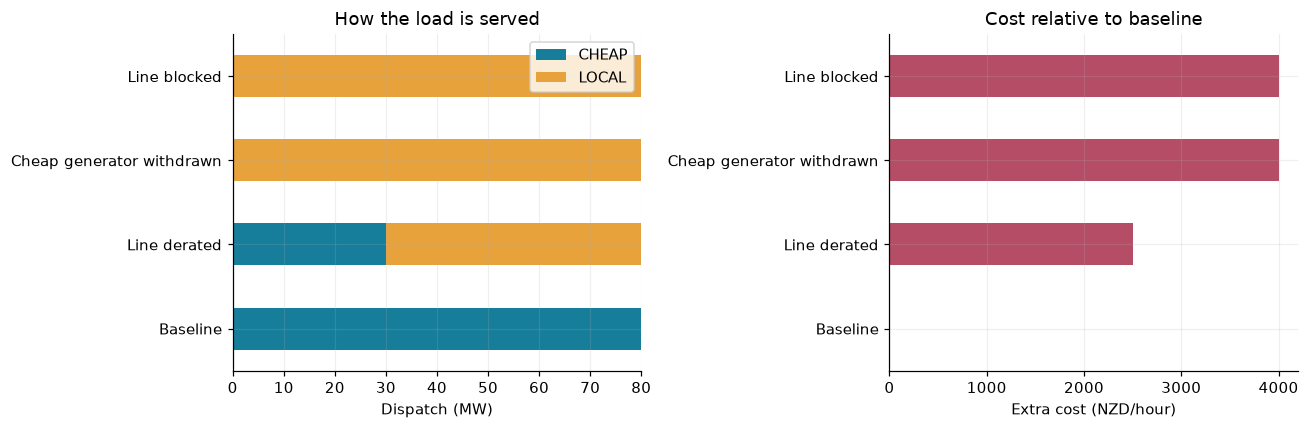

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
scenarios[["CHEAP", "LOCAL"]].plot.barh(
    stacked=True, ax=axes[0], color=["#167d9a", "#e8a23b"]
)
scenarios.extra_cost_nzd_per_hour.plot.barh(ax=axes[1], color="#b54d67")
axes[0].set(xlabel="Dispatch (MW)", ylabel="", title="How the load is served")
axes[1].set(
    xlabel="Extra cost (NZD/hour)", ylabel="", title="Cost relative to baseline"
)
fig.tight_layout()
display(fig)
plt.close(fig)

## Find the useful capacity range

Sample capacities on either side of demand. Avoid interpreting the price at
exactly 80 MW as unique: the line-capacity and dispatch breakpoints coincide.
With zero flow, a price at an isolated economic location can also be nonunique;
the dispatch and cost checks remain the primary conclusions.

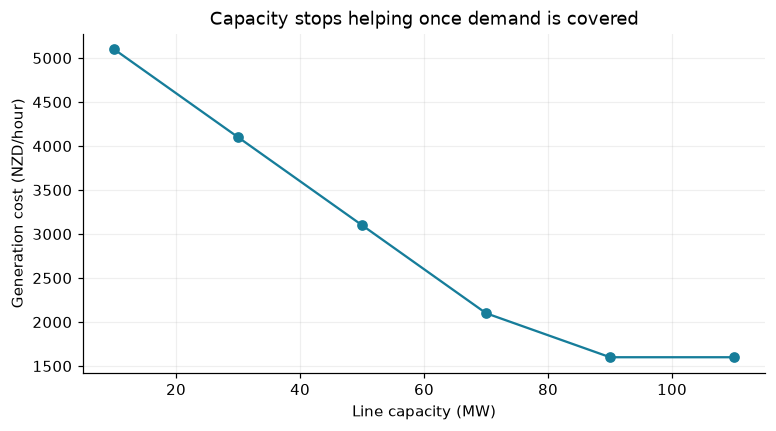

In [9]:
capacity_sweep = pd.DataFrame(
    {"capacity_mw": cap, **solve_network(network_case(line_capacity=cap))}
    for cap in [10.0, 30.0, 50.0, 70.0, 90.0, 110.0]
)
assert capacity_sweep.cost_nzd_per_hour.is_monotonic_decreasing
fig, ax = plt.subplots()
ax.plot(
    capacity_sweep.capacity_mw, capacity_sweep.cost_nzd_per_hour, "o-", color="#167d9a"
)
ax.set(
    xlabel="Line capacity (MW)",
    ylabel="Generation cost (NZD/hour)",
    title="Capacity stops helping once demand is covered",
)
display(fig)
plt.close(fig)

## Try it

Raise demand to 110 MW and compare the same scenarios. This notebook assumes
load can always be served. A study of lost load must explicitly inspect deficit
quantities and their penalty costs before interpreting the resulting prices.